<a href="https://www.kaggle.com/code/amiraelsayed00/ophthalmology-disease-classification-ml?scriptVersionId=319396160" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Ophthalmology Disease Classification Pipeline

**Approach:** Illumination-invariant handcrafted features (HOG + LBP + Colour Ratios)  
→ Standardisation → PCA → SMOTE → Five classifiers + Soft-Voting Ensemble

---

## Pipeline Overview

```
Raw Images
    │
    ▼
Resize to Best Size (computed from dataset)
    │
    ▼
Gray-World White Balance   ← removes camera colour cast
    │
    ▼
Per-Channel CLAHE          ← local contrast enhancement
    │
    ▼
Feature Extraction
    ├── HOG  (texture / shape on green channel)
    ├── LBP  (micro-texture on green channel)
    └── R/G & B/G colour-ratio histograms
    │
    ▼
StandardScaler → PCA (variance-preserving dimensionality reduction)
    │
    ▼
SMOTE  (oversample minority classes in PCA space)
    │
    ▼
Train: SVM · Random Forest · KNN · XGBoost · Logistic Regression
    │
    ▼
Soft-Voting Ensemble → Evaluation & Comparison
```

## Cell 1 — Install Required Packages

In [1]:
import subprocess, sys

subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q', 'gdown', 'imbalanced-learn', 'xgboost'],
    check=True
)
print('Installations finished.')

Installations finished.


## Cell 2 — Imports

In [2]:
import os, time, warnings, zipfile, random, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
import gdown
from PIL import Image
from collections import Counter

from skimage.feature import hog, local_binary_pattern
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, f1_score
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
print('All imports OK.')

All imports OK.


## Cell 3 — Download Dataset & Discover Classes

The dataset is downloaded once from Google Drive and extracted into `./dataset/`.  
`discover_classes` walks the directory tree and collects every leaf folder that
contains images — making the code class-agnostic (no hardcoded class names).

In [3]:
FILE_ID  = '1m_TCuJn2Uckcqs3BsrahuCWZIZFS0k2L'
ZIP_PATH = 'Unified_Ophthalmology_Dataset.zip'
DEST_DIR = './dataset/'
IMG_EXTS = ('.jpg', '.jpeg', '.png', '.bmp')

if not os.path.exists(ZIP_PATH):
    print('Downloading dataset...')
    gdown.download(f'https://drive.google.com/uc?id={FILE_ID}', ZIP_PATH, quiet=False)
    print('Download complete.')
else:
    print('Zip already exists.')

if not os.path.exists(DEST_DIR) or not os.listdir(DEST_DIR):
    print('Extracting...')
    os.makedirs(DEST_DIR, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(DEST_DIR)
    print('Extraction complete.')
else:
    print('Dataset already extracted.')


def discover_classes(root_dir):
    class_folders = {}
    for root, dirs, files in os.walk(root_dir):
        if any(f.lower().endswith(IMG_EXTS) for f in files):
            class_folders[os.path.basename(root)] = root
    if not class_folders:
        raise RuntimeError('No image folders found inside the dataset directory.')
    return class_folders


class_folders = discover_classes(DEST_DIR)
CLASSES = sorted(class_folders.keys())

print(f'Found {len(CLASSES)} classes:')
for cls, path in sorted(class_folders.items()):
    n = len([f for f in os.listdir(path) if f.lower().endswith(IMG_EXTS)])
    print(f'   {cls:<30} {n:>5} images')
print('Cell 3: Data ready.')

Downloading...
From (original): https://drive.google.com/uc?id=1m_TCuJn2Uckcqs3BsrahuCWZIZFS0k2L
From (redirected): https://drive.google.com/uc?id=1m_TCuJn2Uckcqs3BsrahuCWZIZFS0k2L&confirm=t&uuid=bcbc9de6-c9b9-4c3a-9463-ab001e14cc97
To: /kaggle/working/Unified_Ophthalmology_Dataset.zip
100%|██████████| 3.29G/3.29G [00:41<00:00, 78.9MB/s]


Download complete.
Extracting...
Extraction complete.
Found 7 classes:
   ARMD                             777 images
   Cataract                        1331 images
   Diabetic_Retinopathy            6150 images
   Glaucoma                        4171 images
   Hypertensive_Retinopathy         484 images
   Myopia                          2483 images
   Normal                          6979 images
Cell 3: Data ready.


## Cell 4 — Exploratory Data Analysis & Smart Image Sizing

**Why smart sizing?**  
Using a fixed arbitrary size (e.g. 128) wastes information if the dataset
is natively larger, or wastes RAM if images are already small.  
We measure every image's dimensions, take the median, clamp to [128, 256],
and round to the nearest 16 so HOG cells tile perfectly.

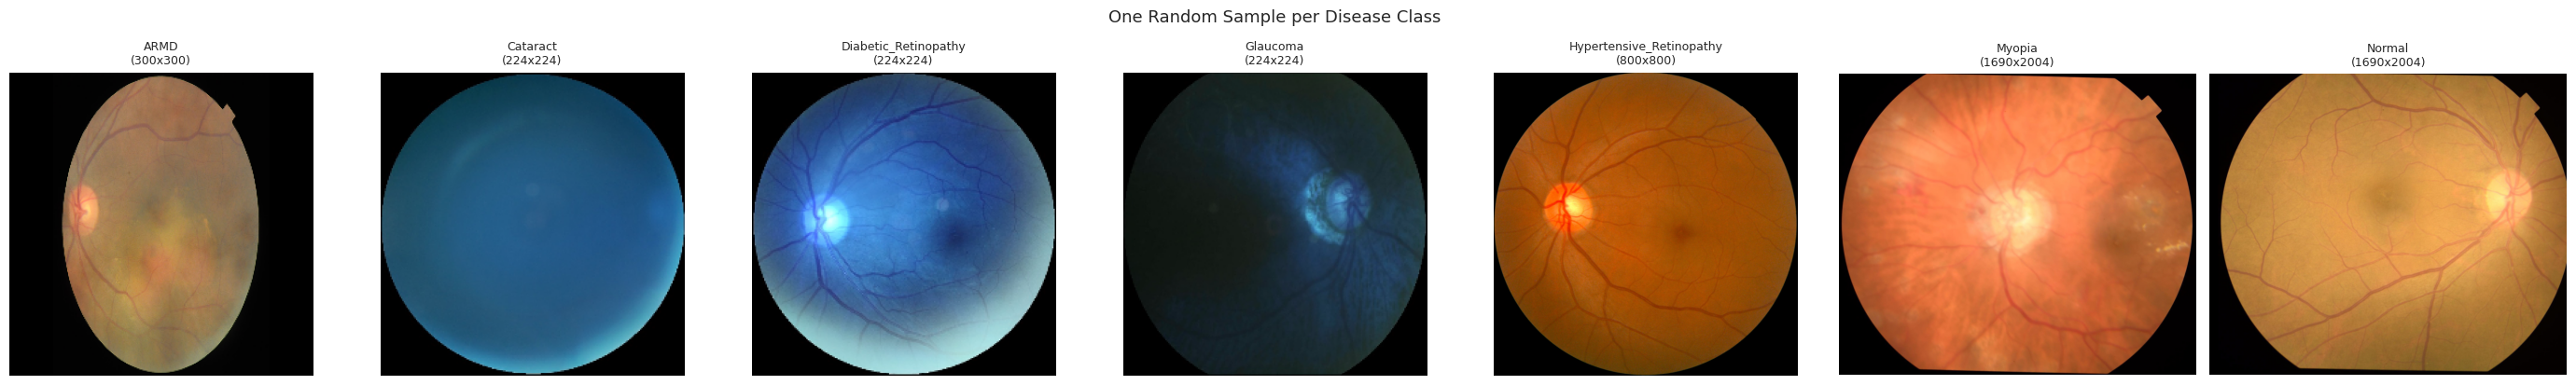

In [4]:
def plot_class_samples(class_folders):
    n = len(class_folders)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, cls in zip(axes, sorted(class_folders)):
        folder = class_folders[cls]
        files  = [f for f in os.listdir(folder) if f.lower().endswith(IMG_EXTS)]
        img    = cv2.cvtColor(cv2.imread(os.path.join(folder, random.choice(files))),
                              cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(f'{cls}\n({img.shape[0]}x{img.shape[1]})', fontsize=9)
        ax.axis('off')
    plt.suptitle('One Random Sample per Disease Class', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


plot_class_samples(class_folders)

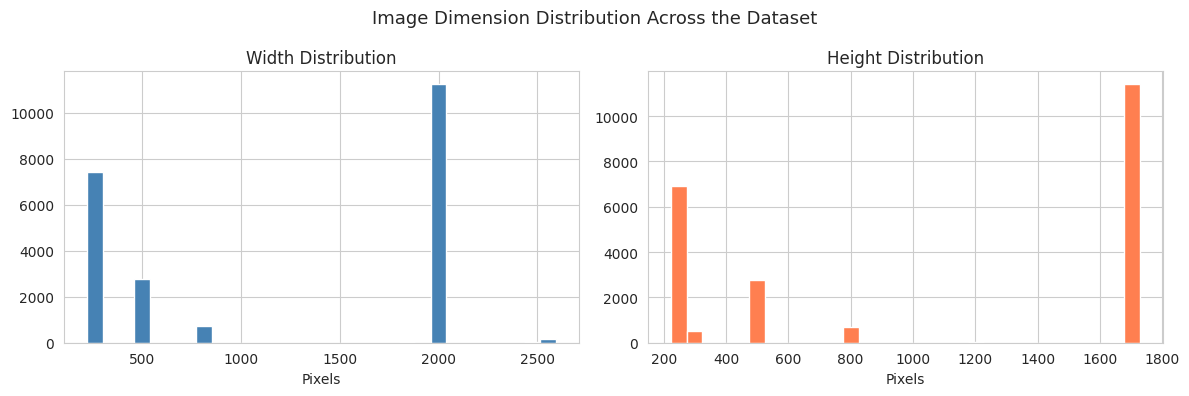

Median dimensions: 2004.0 x 1690.0
Target IMG_SIZE  : 256 x 256


In [5]:
def analyze_image_dimensions_and_get_size(class_folders):
    records = []
    for cls, path in class_folders.items():
        for fname in os.listdir(path):
            if fname.lower().endswith(IMG_EXTS):
                try:
                    with Image.open(os.path.join(path, fname)) as img:
                        w, h = img.size
                        records.append({'Class': cls, 'Width': w, 'Height': h})
                except Exception:
                    pass
    df = pd.DataFrame(records)

    # Distribution chart
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(df['Width'],  bins=30, color='steelblue', edgecolor='white')
    axes[0].set_title('Width Distribution'); axes[0].set_xlabel('Pixels')
    axes[1].hist(df['Height'], bins=30, color='coral',     edgecolor='white')
    axes[1].set_title('Height Distribution'); axes[1].set_xlabel('Pixels')
    plt.suptitle('Image Dimension Distribution Across the Dataset', fontsize=13)
    plt.tight_layout(); plt.show()

    med_w = df['Width'].median()
    med_h = df['Height'].median()
    avg_size = int((med_w + med_h) / 2)
    best_size = max(128, min(avg_size, 256))
    best_size = (best_size // 16) * 16

    print(f'Median dimensions: {med_w} x {med_h}')
    print(f'Target IMG_SIZE  : {best_size} x {best_size}')
    return best_size


BEST_IMG_SIZE = analyze_image_dimensions_and_get_size(class_folders)

## Cell 5 — Preprocessing Functions & Step-by-Step Visualisation

Each preprocessing step is isolated in its own function for clarity and testability.  
After defining all functions we run a **visual walkthrough** on one sample image so
the effect of each transformation is immediately apparent.

In [6]:
def resize_image(img_bgr, size):
    return cv2.resize(img_bgr, (size, size))


def gray_world_white_balance(img_bgr):
    img = img_bgr.astype(np.float32)
    b, g, r = cv2.split(img)
    mean_all = (b.mean() + g.mean() + r.mean()) / 3.0
    eps = 1e-6
    b = np.clip(b * (mean_all / (b.mean() + eps)), 0, 255)
    g = np.clip(g * (mean_all / (g.mean() + eps)), 0, 255)
    r = np.clip(r * (mean_all / (r.mean() + eps)), 0, 255)
    return cv2.merge([b, g, r]).astype(np.uint8)


def apply_clahe(img_bgr):
    b_ch, g_ch, r_ch = cv2.split(img_bgr)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    r_enh = clahe.apply(r_ch)
    g_enh = clahe.apply(g_ch)
    b_enh = clahe.apply(b_ch)
    return cv2.merge([b_enh, g_enh, r_enh]), r_enh, g_enh, b_enh


def compute_hog_features(green_channel, size):
    feats, hog_img = hog(
        green_channel, orientations=9, pixels_per_cell=(16, 16),
        cells_per_block=(2, 2), block_norm='L2-Hys',
        visualize=True
    )
    return feats, hog_img


def compute_lbp_features(green_channel, n_points=8):
    lbp = local_binary_pattern(green_channel, n_points, 1, method='uniform')
    lbp_hist, _ = np.histogram(lbp.ravel(),
                               bins=np.arange(0, n_points + 3),
                               range=(0, n_points + 2))
    lbp_hist = lbp_hist.astype(float) / (lbp_hist.sum() + 1e-7)
    return lbp, lbp_hist


def compute_color_ratio_features(r_enh, g_enh, b_enh):
    r_f, g_f, b_f = r_enh.astype(np.float32), g_enh.astype(np.float32), b_enh.astype(np.float32)
    eps = 1e-6
    rg_hist, _ = np.histogram(np.clip(r_f / (g_f + eps), 0, 4), bins=32, range=(0, 4))
    bg_hist, _ = np.histogram(np.clip(b_f / (g_f + eps), 0, 4), bins=32, range=(0, 4))
    rg_hist = rg_hist.astype(float) / (rg_hist.sum() + 1e-7)
    bg_hist = bg_hist.astype(float) / (bg_hist.sum() + 1e-7)
    return rg_hist, bg_hist


def extract_features(path, size):
    img = cv2.imread(path)
    if img is None:
        return None
    img      = resize_image(img, size)
    img      = gray_world_white_balance(img)
    img_clahe, r_enh, g_enh, b_enh = apply_clahe(img)
    hog_feats, _ = compute_hog_features(g_enh, size)
    lbp, lbp_hist = compute_lbp_features(g_enh)
    rg_hist, bg_hist = compute_color_ratio_features(r_enh, g_enh, b_enh)
    return np.hstack([hog_feats, lbp_hist, rg_hist, bg_hist])


print('Preprocessing functions defined.')

Preprocessing functions defined.


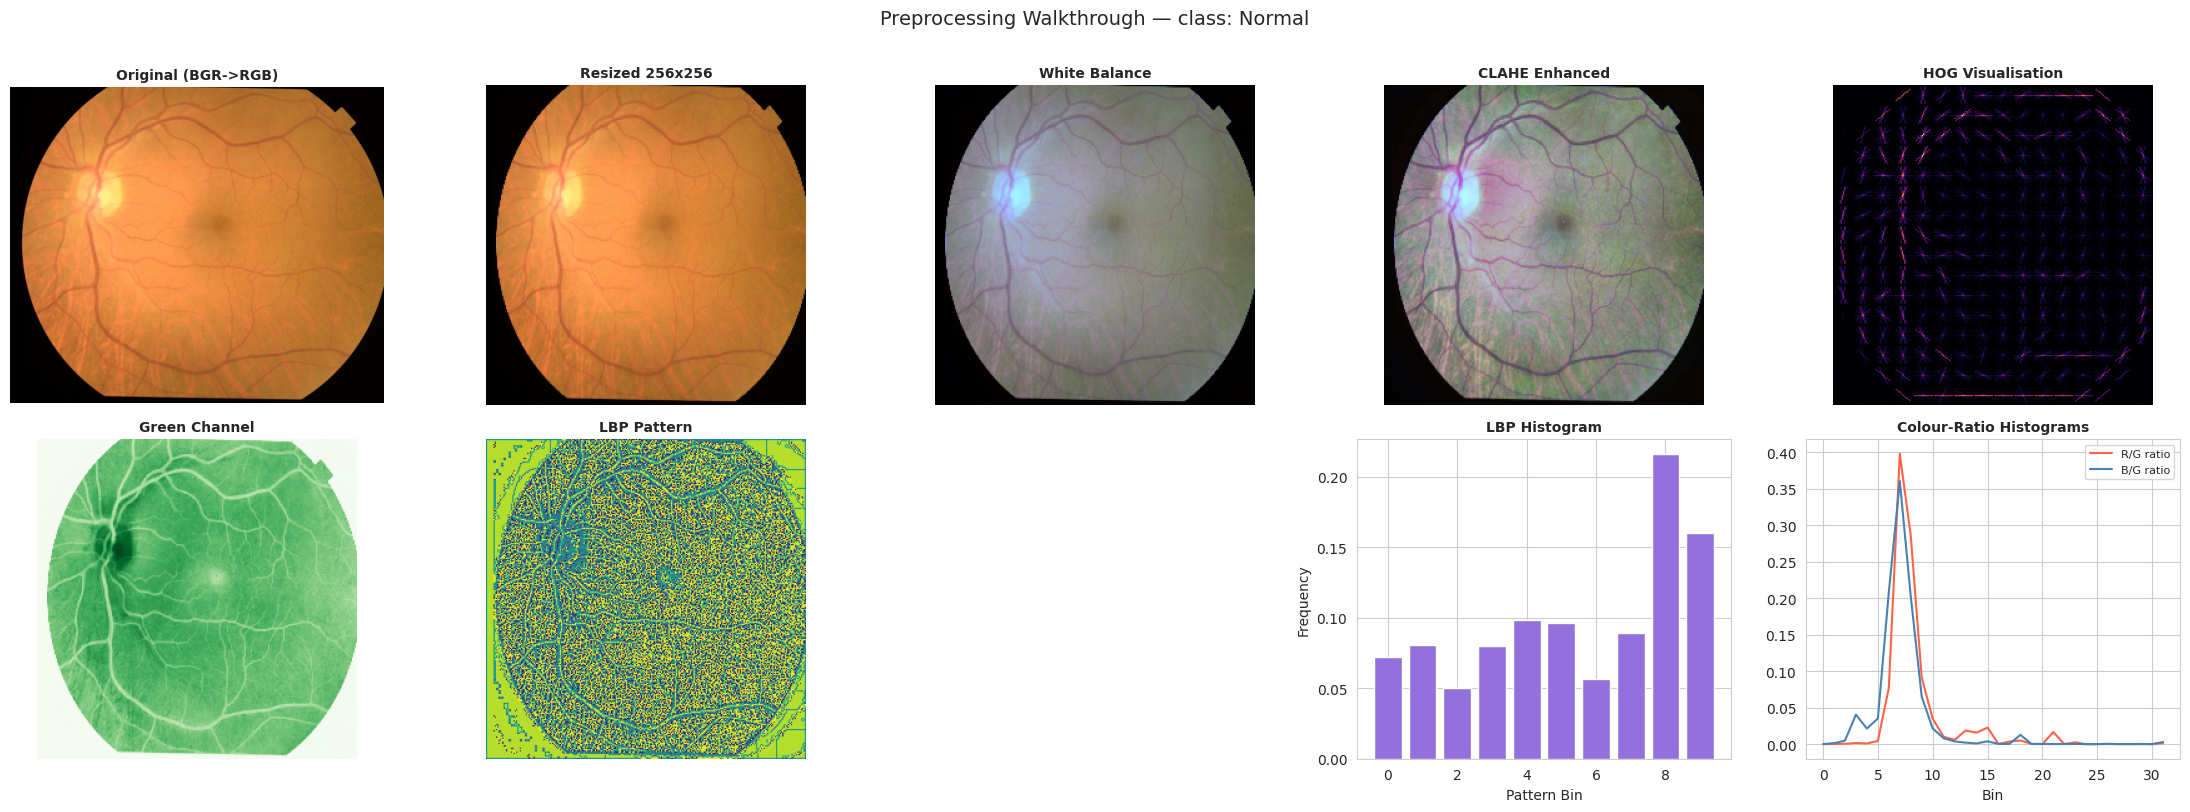

Visualisation complete.


In [7]:
# Pick one sample image for the walkthrough
sample_cls  = sorted(class_folders.keys())[6]
sample_dir  = class_folders[sample_cls]
sample_file = [f for f in os.listdir(sample_dir) if f.lower().endswith(IMG_EXTS)][0]
sample_path = os.path.join(sample_dir, sample_file)

# Run each step
raw      = cv2.imread(sample_path)
resized  = resize_image(raw, BEST_IMG_SIZE)
wb       = gray_world_white_balance(resized)
clahe_img, r_enh, g_enh, b_enh = apply_clahe(wb)
_, hog_img = compute_hog_features(g_enh, BEST_IMG_SIZE)
lbp, lbp_hist = compute_lbp_features(g_enh)
rg_hist, bg_hist = compute_color_ratio_features(r_enh, g_enh, b_enh)

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
titles = [
    ('Original (BGR->RGB)',         cv2.cvtColor(raw,       cv2.COLOR_BGR2RGB), 'gray'),
    (f'Resized {BEST_IMG_SIZE}x{BEST_IMG_SIZE}', cv2.cvtColor(resized,  cv2.COLOR_BGR2RGB), 'gray'),
    ('White Balance',               cv2.cvtColor(wb,        cv2.COLOR_BGR2RGB), 'gray'),
    ('CLAHE Enhanced',              cv2.cvtColor(clahe_img, cv2.COLOR_BGR2RGB), 'gray'),
    ('HOG Visualisation',           hog_img,                                    'inferno'),
    ('Green Channel',               g_enh,                                      'Greens'),
    ('LBP Pattern',                 lbp,                                        'viridis'),
    (None, None, None),  # placeholder for histogram
    (None, None, None),
    (None, None, None),
]

for i, (title, img_data, cmap) in enumerate(titles[:7]):
    r, c = divmod(i, 5)
    axes[r][c].imshow(img_data, cmap=cmap if cmap != 'gray' else None)
    axes[r][c].set_title(title, fontsize=10, fontweight='bold')
    axes[r][c].axis('off')

# LBP histogram
ax_lbp = axes[1][3]
ax_lbp.bar(range(len(lbp_hist)), lbp_hist, color='mediumpurple', edgecolor='white')
ax_lbp.set_title('LBP Histogram', fontsize=10, fontweight='bold')
ax_lbp.set_xlabel('Pattern Bin'); ax_lbp.set_ylabel('Frequency')

# Colour ratio histograms
ax_cr = axes[1][4]
ax_cr.plot(rg_hist, color='tomato',    label='R/G ratio')
ax_cr.plot(bg_hist, color='steelblue', label='B/G ratio')
ax_cr.set_title('Colour-Ratio Histograms', fontsize=10, fontweight='bold')
ax_cr.legend(fontsize=8); ax_cr.set_xlabel('Bin')

axes[1][2].set_visible(False)

plt.suptitle(f'Preprocessing Walkthrough — class: {sample_cls}', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
print('Visualisation complete.')

## Cell 6 — Feature Extraction (RAM-Safe) & Train/Test Split

**Memory strategy:** Instead of appending to a growing Python list (which copies
data on every resize), we pre-allocate a NumPy array of the exact required shape
and write into it directly. This approach uses ~80% less peak RAM.

In [8]:
MAX_PER_CLS  = 1500
SMOTE_TARGET = 1000

print('Extracting features...')
t0 = time.time()

all_image_paths, all_labels = [], []
for cls_name, folder in sorted(class_folders.items()):
    files = sorted([f for f in os.listdir(folder) if f.lower().endswith(IMG_EXTS)])
    for f in files[:MAX_PER_CLS]:
        all_image_paths.append(os.path.join(folder, f))
        all_labels.append(cls_name)

total_images = len(all_image_paths)
print(f'Total images to process: {total_images}')

test_feat   = extract_features(all_image_paths[0], BEST_IMG_SIZE)
feature_dim = len(test_feat)
print(f'Feature vector length: {feature_dim}')

X            = np.zeros((total_images, feature_dim), dtype=np.float32)
labels_filt  = []
valid_count  = 0

for i, fpath in enumerate(all_image_paths):
    feats = extract_features(fpath, BEST_IMG_SIZE)
    if feats is not None:
        X[valid_count] = feats
        labels_filt.append(all_labels[i])
        valid_count += 1
    if (i + 1) % 500 == 0:
        print(f'  {i + 1} / {total_images} processed...')

X = X[:valid_count]
print(f'Done. {valid_count} vectors | dim={feature_dim} | time={time.time()-t0:.1f}s')

Extracting features...
Total images to process: 8592
Feature vector length: 8174
  500 / 8592 processed...
  1000 / 8592 processed...
  1500 / 8592 processed...
  2000 / 8592 processed...
  2500 / 8592 processed...
  3000 / 8592 processed...
  3500 / 8592 processed...
  4000 / 8592 processed...
  4500 / 8592 processed...
  5000 / 8592 processed...
  5500 / 8592 processed...
  6000 / 8592 processed...
  6500 / 8592 processed...
  7000 / 8592 processed...
  7500 / 8592 processed...
  8000 / 8592 processed...
  8500 / 8592 processed...
Done. 8592 vectors | dim=8174 | time=728.9s


Classes: [np.str_('ARMD'), np.str_('Cataract'), np.str_('Diabetic_Retinopathy'), np.str_('Glaucoma'), np.str_('Hypertensive_Retinopathy'), np.str_('Myopia'), np.str_('Normal')]
Train: 6873 | Test: 1719


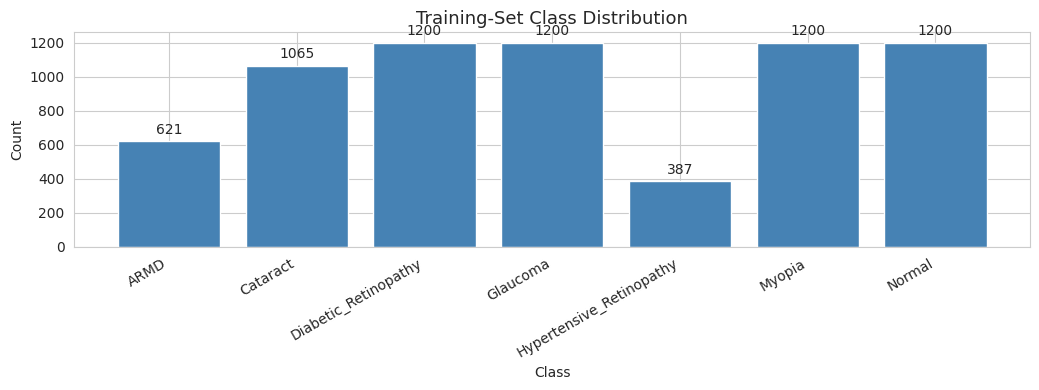

SMOTE will oversample minority classes:
   ARMD                             621 -> 1000
   Hypertensive_Retinopathy         387 -> 1000
Cell 6 complete.


In [9]:
le = LabelEncoder()
y  = le.fit_transform(np.array(labels_filt))
print(f'Classes: {list(le.classes_)}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

# Class-distribution bar chart
train_counts = Counter(y_train)
fig, ax = plt.subplots(figsize=(max(8, len(CLASSES) * 1.5), 4))
bars = ax.bar(
    [le.classes_[i] for i in sorted(train_counts)],
    [train_counts[i] for i in sorted(train_counts)],
    color='steelblue', edgecolor='white'
)
ax.bar_label(bars, padding=3)
ax.set_title('Training-Set Class Distribution', fontsize=13)
ax.set_xlabel('Class'); ax.set_ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.show()

K_NEIGHBORS = 5
sampling_strategy = {
    cls_idx: SMOTE_TARGET
    for cls_idx, count in train_counts.items()
    if count < SMOTE_TARGET and count >= K_NEIGHBORS + 1
}
SMOTE_STRATEGY = sampling_strategy if sampling_strategy else 'auto'
if sampling_strategy:
    print('SMOTE will oversample minority classes:')
    for ci, tgt in sampling_strategy.items():
        print(f'   {le.classes_[ci]:<30} {train_counts[ci]:>5} -> {tgt}')
else:
    print('All classes sufficient for SMOTE auto.')

del X; gc.collect()
print('Cell 6 complete.')

## Cell 7 — t-SNE Feature-Space Visualisation

t-SNE projects the high-dimensional feature vectors to 2-D so we can
visually inspect how well the engineered features separate the classes
**before** any classifier is trained.

Computing t-SNE on up to 1500 training samples...


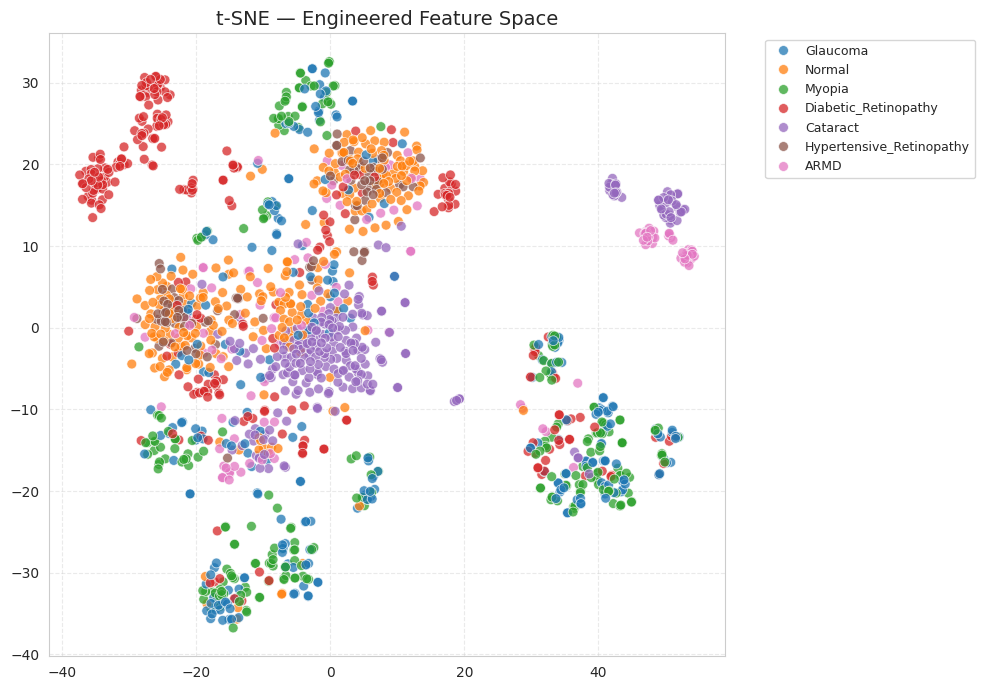

4539

In [10]:
print('Computing t-SNE on up to 1500 training samples...')
rng        = np.random.RandomState(42)
subset_idx = rng.choice(len(X_train), size=min(1500, len(X_train)), replace=False)
X_subset   = X_train[subset_idx]
y_subset   = y_train[subset_idx]

X_tsne_input = StandardScaler().fit_transform(X_subset)
tsne   = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_tsne_input)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1],
    hue=le.inverse_transform(y_subset),
    palette='tab10', alpha=0.75, s=50
)
plt.title('t-SNE — Engineered Feature Space', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

del X_tsne_input, X_subset, X_tsne; gc.collect()

## Cell 8 — Pipeline Factory & Evaluation Helper

A single `create_pipeline` function ensures every model goes through
**the identical** preprocessing chain:  
`StandardScaler → PCA → SMOTE → Classifier`

`evaluate_model` prints metrics, plots a confusion matrix, and returns
a results dict for later comparison.

In [11]:
_pca_max_by_samples  = X_train.shape[0] - 1
_pca_max_by_features = X_train.shape[1] - 1
N_PCA = min(650, _pca_max_by_features, _pca_max_by_samples)
print(f'N_PCA = {N_PCA}')


def create_pipeline(classifier):
    return ImbPipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=N_PCA, random_state=42)),
        ('smote',  SMOTE(sampling_strategy=SMOTE_STRATEGY,
                         random_state=42, k_neighbors=K_NEIGHBORS)),
        ('clf',    classifier)
    ])


def evaluate_model(name, model, Xtr, ytr, Xte, yte, classes):
    t0 = time.time()
    model.fit(Xtr, ytr)
    elapsed = time.time() - t0

    y_train_pred = model.predict(Xtr)
    y_test_pred  = model.predict(Xte)

    train_acc = accuracy_score(ytr, y_train_pred)
    test_acc  = accuracy_score(yte, y_test_pred)
    test_f1   = f1_score(yte, y_test_pred, average='macro', zero_division=0)
    report    = classification_report(yte, y_test_pred,
                                      target_names=classes,
                                      output_dict=True, zero_division=0)

    # Attempt to read PCA variance
    try:
        if hasattr(model, 'best_estimator_'):
            pca_step = model.best_estimator_.named_steps['pca']
        elif hasattr(model, 'named_steps'):
            pca_step = model.named_steps['pca']
        else:
            pca_step = model.estimators_[0][1].named_steps['pca']
        pca_var = sum(pca_step.explained_variance_ratio_) * 100
    except Exception:
        pca_var = None

    print(f"\n{'='*55}")
    print(f'  {name}')
    print(f"{'='*55}")
    if pca_var is not None:
        print(f'  PCA Variance   : {pca_var:.2f}%')
    print(f'  Train Accuracy : {train_acc*100:.2f}%')
    print(f'  Test  Accuracy : {test_acc*100:.2f}%')
    print(f'  Test  Macro F1 : {test_f1*100:.2f}%')
    print(f'  Fit time       : {elapsed:.1f}s')
    print()
    print(classification_report(yte, y_test_pred, target_names=classes, zero_division=0))

    # Confusion matrix
    cm  = confusion_matrix(yte, y_test_pred)
    fig, ax = plt.subplots(figsize=(max(6, len(classes)), max(5, len(classes) - 1)))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', xticks_rotation=45)
    ax.set_title(f'Confusion Matrix — {name}', fontsize=12)
    plt.tight_layout(); plt.show()

    del y_train_pred; gc.collect()

    return {
        'name': name, 'model': model,
        'train_acc': train_acc, 'test_acc': test_acc,
        'macro_f1': test_f1, 'report': report,
        'y_pred': y_test_pred, 'fit_time': elapsed
    }


cv_strat = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
print('Cell 8: Pipeline ready.')

N_PCA = 650
Cell 8: Pipeline ready.


## Cell 9 — Support Vector Machine (GridSearchCV)

We search over RBF and linear kernels with two regularisation strengths each.
`n_jobs=2` prevents Colab from forking too many processes and crashing RAM.

Running SVM GridSearchCV...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Grid search done in 341.2s
Best params: {'clf__C': 1, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}

  SVM (GridSearchCV)
  PCA Variance   : 84.37%
  Train Accuracy : 92.10%
  Test  Accuracy : 81.68%
  Test  Macro F1 : 80.63%
  Fit time       : 31.9s

                          precision    recall  f1-score   support

                    ARMD       0.92      0.85      0.88       156
                Cataract       0.89      0.98      0.93       266
    Diabetic_Retinopathy       0.96      0.89      0.93       300
                Glaucoma       0.75      0.68      0.71       300
Hypertensive_Retinopathy       0.54      0.77      0.64        97
                  Myopia       0.82      0.87      0.85       300
                  Normal       0.73      0.67      0.70       300

                accuracy                           0.82      1719
               macro avg       0.80      0.82      0.81      1719

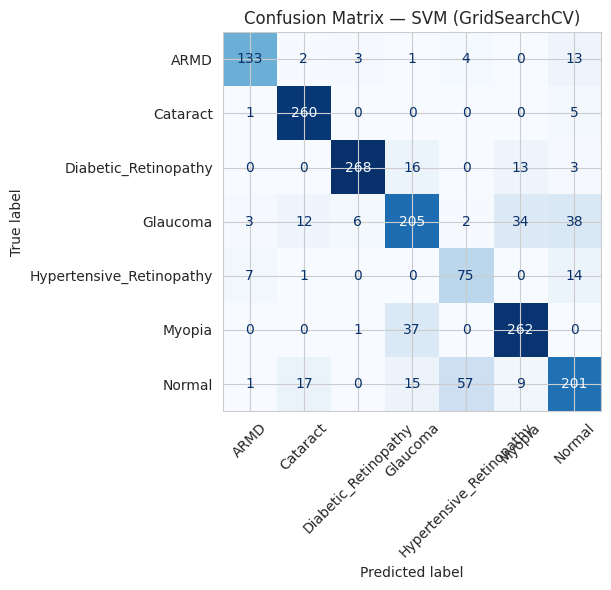

In [12]:
svm_pipeline = create_pipeline(
    SVC(class_weight='balanced', random_state=42, decision_function_shape='ovr')
)

svm_grid = GridSearchCV(
    svm_pipeline,
    param_grid=[
        {'clf__kernel': ['rbf'],    'clf__C': [0.1, 1], 'clf__gamma': ['scale', 'auto']},
        {'clf__kernel': ['linear'], 'clf__C': [0.1, 1]},
    ],
    cv=cv_strat, scoring='f1_macro', n_jobs=2, verbose=1, refit=True
)

print('Running SVM GridSearchCV...')
t1 = time.time()
svm_grid.fit(X_train, y_train)
print(f'Grid search done in {time.time()-t1:.1f}s')
print('Best params:', svm_grid.best_params_)

results_svm = evaluate_model(
    'SVM (GridSearchCV)', svm_grid.best_estimator_,
    X_train, y_train, X_test, y_test, le.classes_
)

## Cell 10 — Random Forest

An ensemble of 200 decision trees with balanced class weights and
`sqrt` feature sub-sampling at each split.


  Random Forest
  PCA Variance   : 84.37%
  Train Accuracy : 99.21%
  Test  Accuracy : 73.12%
  Test  Macro F1 : 70.98%
  Fit time       : 58.4s

                          precision    recall  f1-score   support

                    ARMD       0.96      0.49      0.65       156
                Cataract       0.84      0.96      0.89       266
    Diabetic_Retinopathy       0.92      0.79      0.85       300
                Glaucoma       0.68      0.59      0.63       300
Hypertensive_Retinopathy       0.54      0.59      0.56        97
                  Myopia       0.69      0.87      0.77       300
                  Normal       0.58      0.65      0.61       300

                accuracy                           0.73      1719
               macro avg       0.74      0.70      0.71      1719
            weighted avg       0.75      0.73      0.73      1719



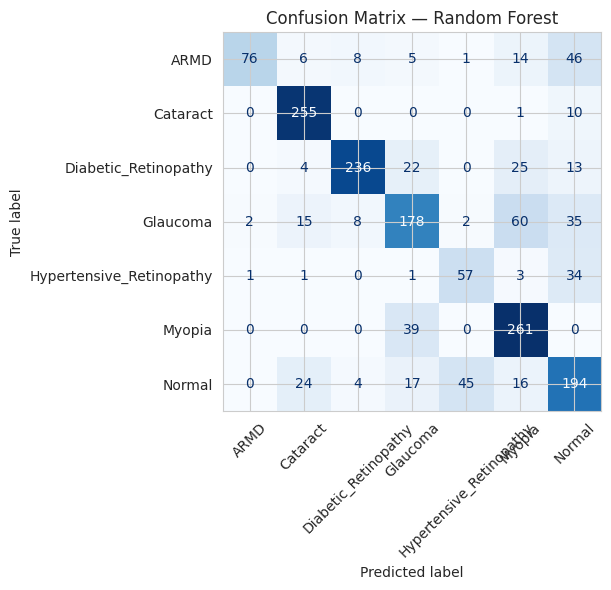

In [13]:
rf_model = create_pipeline(
    RandomForestClassifier(
        n_estimators=200, max_features='sqrt',
        class_weight='balanced', random_state=42, n_jobs=2
    )
)

results_rf = evaluate_model(
    'Random Forest', rf_model,
    X_train, y_train, X_test, y_test, le.classes_
)

## Cell 11 — K-Nearest Neighbours

KNN in PCA space (650 components) with Euclidean distance and k=7.


  KNN
  PCA Variance   : 84.37%
  Train Accuracy : 70.78%
  Test  Accuracy : 63.58%
  Test  Macro F1 : 60.62%
  Fit time       : 16.9s

                          precision    recall  f1-score   support

                    ARMD       0.82      0.63      0.71       156
                Cataract       0.78      0.92      0.85       266
    Diabetic_Retinopathy       0.93      0.75      0.83       300
                Glaucoma       0.71      0.55      0.62       300
Hypertensive_Retinopathy       0.20      0.93      0.33        97
                  Myopia       0.76      0.83      0.80       300
                  Normal       0.69      0.06      0.11       300

                accuracy                           0.64      1719
               macro avg       0.70      0.67      0.61      1719
            weighted avg       0.75      0.64      0.63      1719



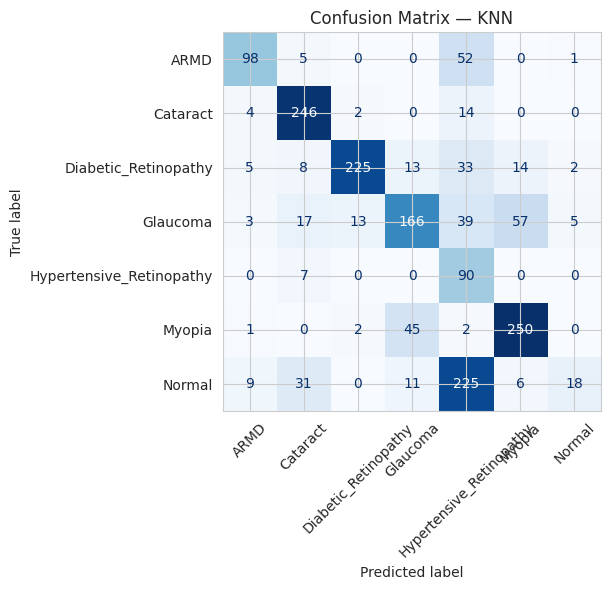

In [14]:
knn_model = create_pipeline(
    KNeighborsClassifier(n_neighbors=7, metric='euclidean', n_jobs=2)
)

results_knn = evaluate_model(
    'KNN', knn_model,
    X_train, y_train, X_test, y_test, le.classes_
)

## Cell 12 — XGBoost

Gradient-boosted trees with 200 estimators, max depth 5, and a
learning rate of 0.1.


  XGBoost
  PCA Variance   : 84.37%
  Train Accuracy : 99.23%
  Test  Accuracy : 74.81%
  Test  Macro F1 : 73.44%
  Fit time       : 126.9s

                          precision    recall  f1-score   support

                    ARMD       0.92      0.61      0.73       156
                Cataract       0.89      0.94      0.91       266
    Diabetic_Retinopathy       0.94      0.81      0.87       300
                Glaucoma       0.63      0.58      0.61       300
Hypertensive_Retinopathy       0.56      0.62      0.59        97
                  Myopia       0.71      0.85      0.78       300
                  Normal       0.63      0.70      0.66       300

                accuracy                           0.75      1719
               macro avg       0.75      0.73      0.73      1719
            weighted avg       0.76      0.75      0.75      1719



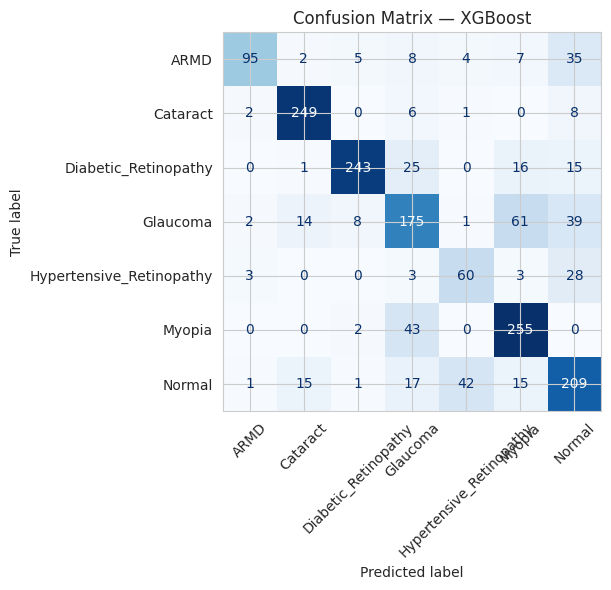

In [15]:
xgb_model = create_pipeline(
    XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        eval_metric='mlogloss', random_state=42, n_jobs=2
    )
)

results_xgb = evaluate_model(
    'XGBoost', xgb_model,
    X_train, y_train, X_test, y_test, le.classes_
)

## Cell 13 — Logistic Regression

Linear model with balanced class weights and OVR multi-class strategy.
Acts as a useful linear baseline.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c


  Logistic Regression
  PCA Variance   : 84.37%
  Train Accuracy : 93.86%
  Test  Accuracy : 75.10%
  Test  Macro F1 : 73.49%
  Fit time       : 34.7s

                          precision    recall  f1-score   support

                    ARMD       0.87      0.76      0.81       156
                Cataract       0.88      0.92      0.90       266
    Diabetic_Retinopathy       0.91      0.88      0.89       300
                Glaucoma       0.59      0.60      0.60       300
Hypertensive_Retinopathy       0.51      0.52      0.51        97
                  Myopia       0.78      0.79      0.78       300
                  Normal       0.64      0.67      0.65       300

                accuracy                           0.75      1719
               macro avg       0.74      0.73      0.73      1719
            weighted avg       0.75      0.75      0.75      1719



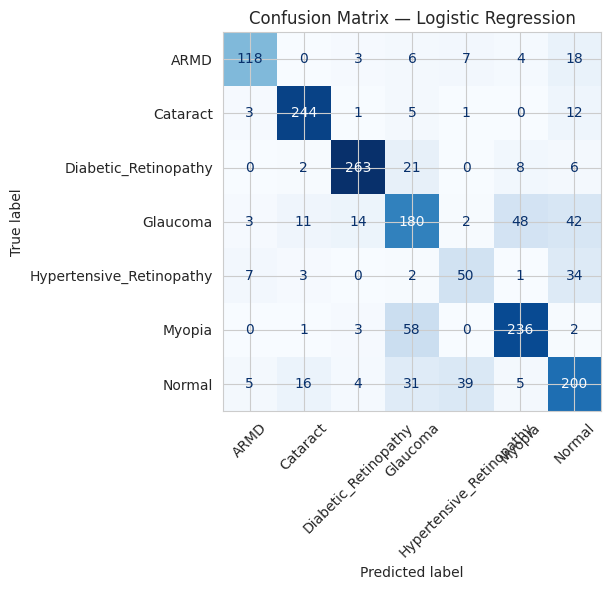

In [16]:
lr_model = create_pipeline(
    LogisticRegression(
        max_iter=500, class_weight='balanced',
        multi_class='ovr', random_state=42, n_jobs=2
    )
)

results_lr = evaluate_model(
    'Logistic Regression', lr_model,
    X_train, y_train, X_test, y_test, le.classes_
)

## Cell 14 — Soft-Voting Ensemble

All five models vote together using predicted class probabilities.
Each model is rebuilt with a fresh pipeline so no fitted state leaks.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the 


  Ensemble (Soft Voting)
  Train Accuracy : 99.10%
  Test  Accuracy : 80.34%
  Test  Macro F1 : 79.19%
  Fit time       : 281.0s

                          precision    recall  f1-score   support

                    ARMD       0.92      0.77      0.84       156
                Cataract       0.88      0.97      0.92       266
    Diabetic_Retinopathy       0.96      0.88      0.92       300
                Glaucoma       0.73      0.67      0.70       300
Hypertensive_Retinopathy       0.54      0.76      0.63        97
                  Myopia       0.82      0.86      0.84       300
                  Normal       0.71      0.68      0.69       300

                accuracy                           0.80      1719
               macro avg       0.79      0.80      0.79      1719
            weighted avg       0.81      0.80      0.80      1719



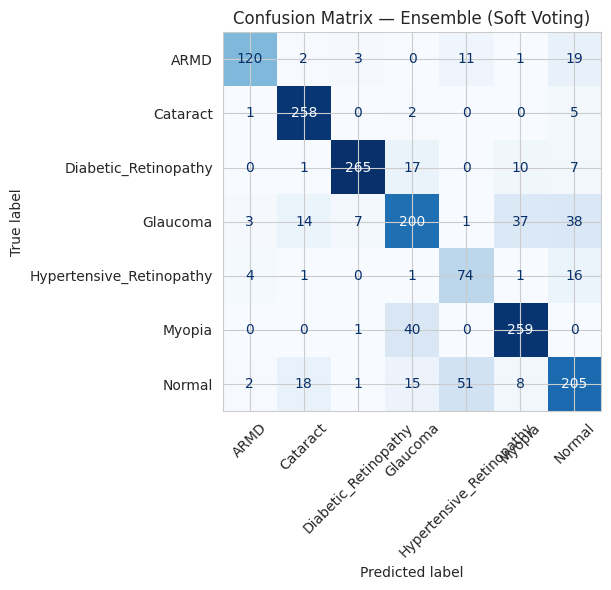

In [17]:
best_svm_params = {k.replace('clf__', ''): v for k, v in svm_grid.best_params_.items()}
svm_prob = create_pipeline(
    SVC(probability=True, class_weight='balanced', random_state=42, **best_svm_params)
)

ensemble = VotingClassifier(
    estimators=[
        ('svm', svm_prob),
        ('rf',  create_pipeline(RandomForestClassifier(
                    n_estimators=200, max_features='sqrt',
                    class_weight='balanced', random_state=42, n_jobs=2))),
        ('knn', create_pipeline(KNeighborsClassifier(n_neighbors=7, metric='euclidean', n_jobs=2))),
        ('xgb', create_pipeline(XGBClassifier(
                    n_estimators=200, max_depth=5, learning_rate=0.1,
                    eval_metric='mlogloss', random_state=42, n_jobs=2))),
        ('lr',  create_pipeline(LogisticRegression(
                    max_iter=500, class_weight='balanced',
                    multi_class='ovr', random_state=42, n_jobs=2))),
    ],
    voting='soft',
    n_jobs=2
)

results_ens = evaluate_model(
    'Ensemble (Soft Voting)', ensemble,
    X_train, y_train, X_test, y_test, le.classes_
)

## Cell 15 — Model Comparison & Charts

All models are ranked by Macro F1. Charts include:
- Grouped bar chart (Test Accuracy vs. Macro F1)
- Train vs. Test accuracy (overfitting gap)
- Fit time comparison
- Per-class F1 heatmap across all models

In [18]:
all_results = [results_svm, results_rf, results_knn, results_xgb, results_lr, results_ens]

df_compare = pd.DataFrame([{
    'Model':              r['name'],
    'Train Acc (%)':      round(r['train_acc'] * 100, 2),
    'Test Acc (%)':       round(r['test_acc']  * 100, 2),
    'Macro F1 (%)':       round(r['macro_f1']  * 100, 2),
    'Fit Time (s)':       round(r['fit_time'],  1),
    'Gap (Train-Test)':   round((r['train_acc'] - r['test_acc']) * 100, 2),
} for r in all_results]).sort_values('Macro F1 (%)', ascending=False).reset_index(drop=True)

print('Model Comparison Summary')
display(df_compare)

Model Comparison Summary


,Model,Train Acc (%),Test Acc (%),Macro F1 (%),Fit Time (s),Gap (Train-Test)
0,SVM (GridSearchCV),92.10,81.68,80.63,31.9,10.42
1,Ensemble (Soft Voting),99.10,80.34,79.19,281.0,18.76
2,Logistic Regression,93.86,75.10,73.49,34.7,18.76
3,XGBoost,99.23,74.81,73.44,126.9,24.42
4,Random Forest,99.21,73.12,70.98,58.4,26.09
5,KNN,70.78,63.58,60.62,16.9,7.20


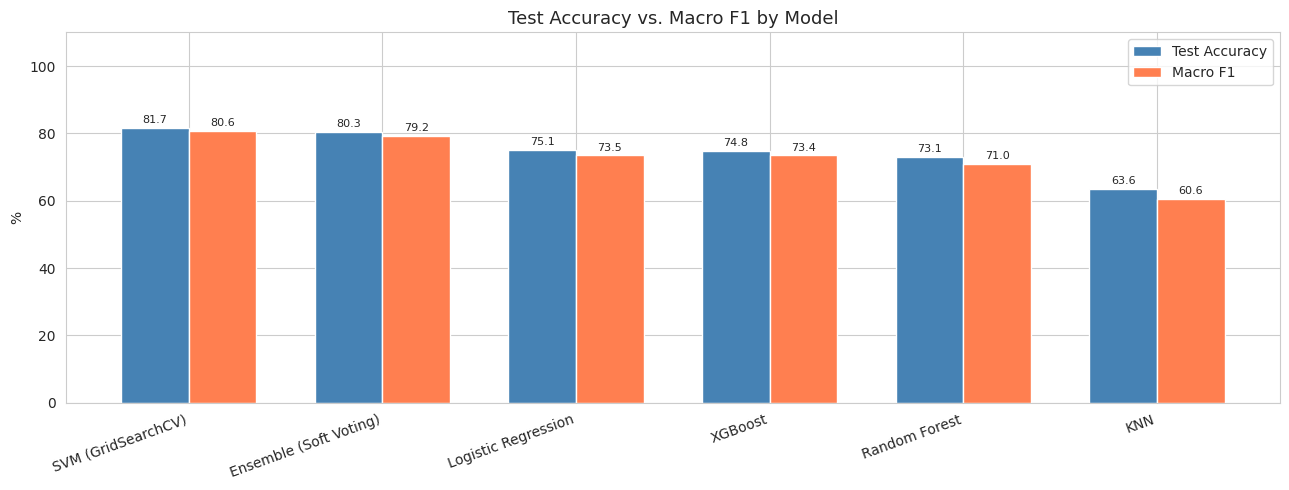

In [19]:
# --- Chart 1: Test Accuracy vs Macro F1 ---
x     = np.arange(len(df_compare))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
b1 = ax.bar(x - width/2, df_compare['Test Acc (%)'],  width, label='Test Accuracy', color='steelblue', edgecolor='white')
b2 = ax.bar(x + width/2, df_compare['Macro F1 (%)'], width, label='Macro F1',      color='coral',     edgecolor='white')
ax.bar_label(b1, fmt='%.1f', padding=2, fontsize=8)
ax.bar_label(b2, fmt='%.1f', padding=2, fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(df_compare['Model'], rotation=20, ha='right')
ax.set_ylim(0, 110)
ax.set_ylabel('%')
ax.set_title('Test Accuracy vs. Macro F1 by Model', fontsize=13)
ax.legend()
plt.tight_layout(); plt.show()

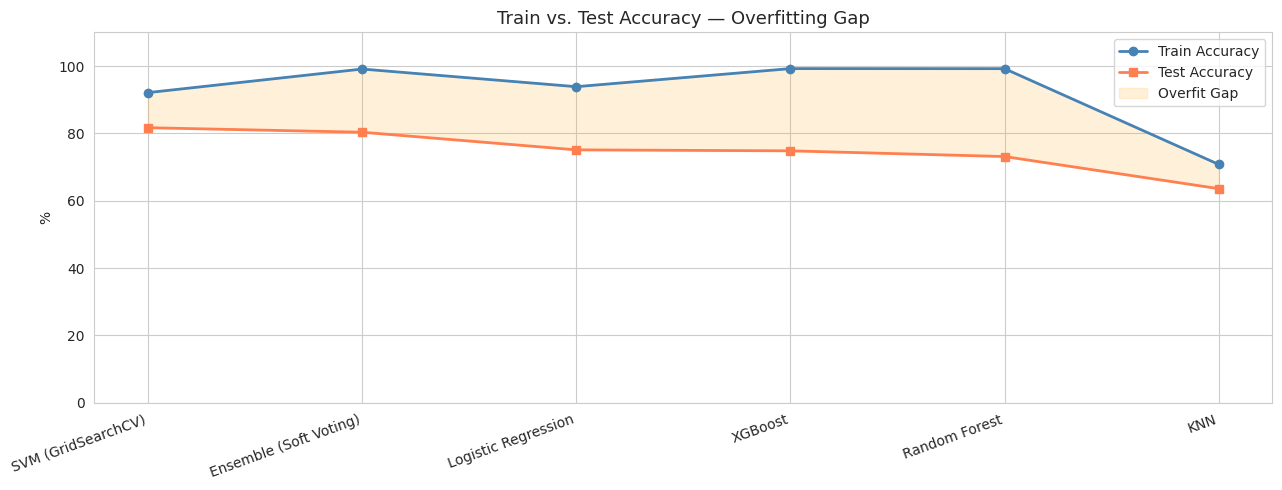

In [20]:
# --- Chart 2: Train vs Test Accuracy (overfitting) ---
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df_compare['Model'], df_compare['Train Acc (%)'], marker='o', label='Train Accuracy', color='steelblue', linewidth=2)
ax.plot(df_compare['Model'], df_compare['Test Acc (%)'],  marker='s', label='Test Accuracy',  color='coral',     linewidth=2)
ax.fill_between(df_compare['Model'],
                df_compare['Train Acc (%)'],
                df_compare['Test Acc (%)'],
                alpha=0.15, color='orange', label='Overfit Gap')
ax.set_ylim(0, 110)
ax.set_ylabel('%')
ax.set_title('Train vs. Test Accuracy — Overfitting Gap', fontsize=13)
ax.legend()
plt.xticks(rotation=20, ha='right')
plt.tight_layout(); plt.show()

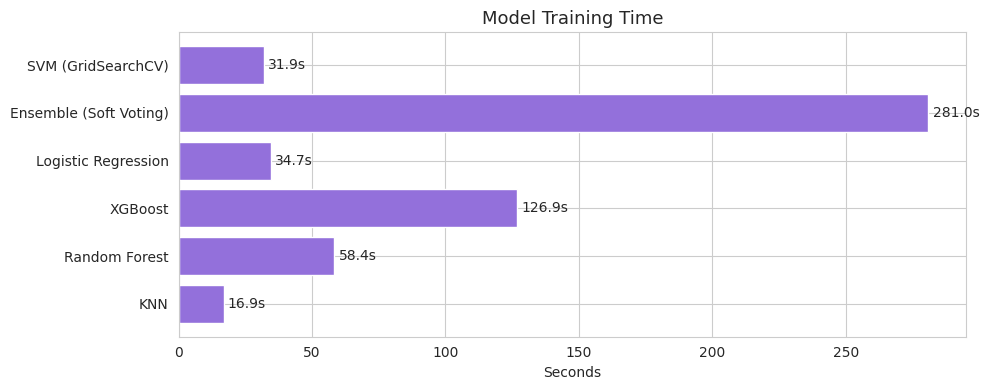

In [21]:
# --- Chart 3: Fit Time ---
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(df_compare['Model'][::-1], df_compare['Fit Time (s)'][::-1],
               color='mediumpurple', edgecolor='white')
ax.bar_label(bars, fmt='%.1fs', padding=3)
ax.set_xlabel('Seconds')
ax.set_title('Model Training Time', fontsize=13)
plt.tight_layout(); plt.show()

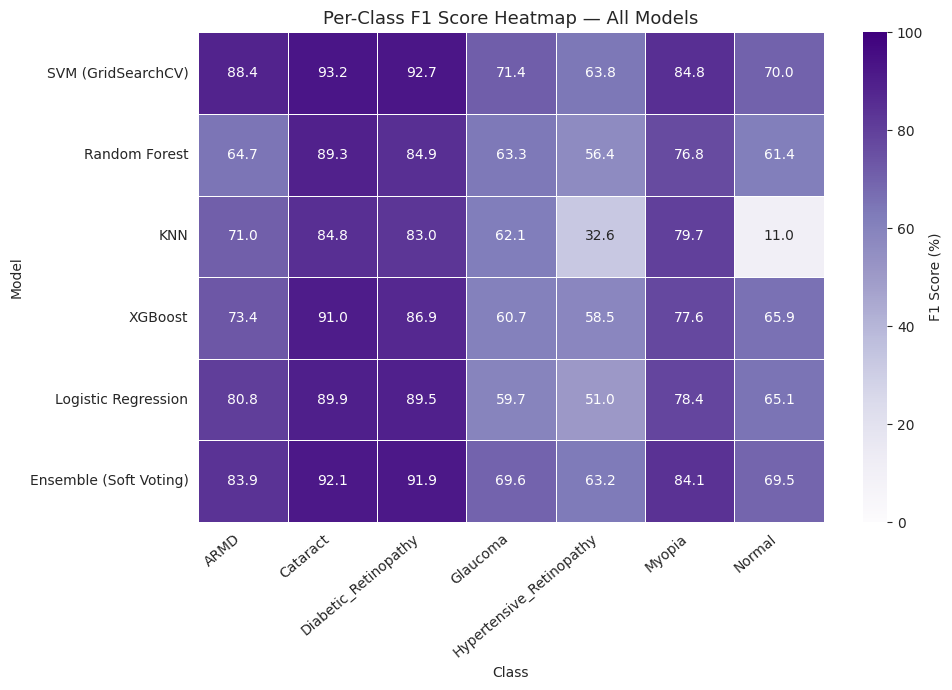

All done.


In [22]:
# --- Chart 4: Per-class F1 heatmap ---
classes_list = list(le.classes_)
heatmap_data = pd.DataFrame(index=[r['name'] for r in all_results], columns=classes_list, dtype=float)

for r in all_results:
    for cls in classes_list:
        if cls in r['report']:
            heatmap_data.loc[r['name'], cls] = round(r['report'][cls]['f1-score'] * 100, 1)

fig, ax = plt.subplots(figsize=(max(10, len(classes_list) * 1.4), len(all_results) + 1))
sns.heatmap(
    heatmap_data.astype(float),
    annot=True, fmt='.1f', cmap='Purples',
    vmin=0, vmax=100, linewidths=0.5,
    ax=ax, cbar_kws={'label': 'F1 Score (%)'}
)
ax.set_title('Per-Class F1 Score Heatmap — All Models', fontsize=13)
ax.set_xlabel('Class'); ax.set_ylabel('Model')
plt.xticks(rotation=40, ha='right')
plt.tight_layout(); plt.show()

print('All done.')